# Geometric & Discriminant Classification: SVM, LDA & QDA

## 1. Theoretical Foundation

In the previous notebook, we classified data using the rules of Probability: Logistic Regression predicted the odds via a Sigmoid curve, and Naive Bayes built distributions using the Gaussian Bell.

Now, we throw probability out the window. Welcome to **Geometric Classification**. 

Instead of asking "what are the odds?", geometric models treat data points as physical coordinates in space. They ask: *"Where can I draw a solid wall to separate these groups perfectly?"* If a new point lands on the left of the wall, it's Class A. If it lands on the right, it's Class B. There are no percentages, just hard geometry.

Behind this simple idea hide some of the most beautiful and powerful mathematical frameworks in Machine Learning:

### 1.1 Support Vector Machines (SVM) & The Margin

If you want to separate two clusters of points, there are infinitely many lines you could draw between them. Which one is best?

**Support Vector Machines (SVM)** argue that the best boundary is the one that stays as far away from both clusters as possible. It tries to maximize the **Margin**: the empty street between the boundary and the closest data points of each class. These closest points are literally holding up the margin; they are the **"Support Vectors"**.

- **Hard Margin:** Assumes perfect separation is possible. If even one point crosses the line, the math breaks.
- **Soft Margin (The "C" parameter):** Allows some points to violate the margin (or even be misclassified) in exchange for finding a wider, more robust street. A high `C` strictly enforces boundaries (overfitting), while a low `C` allows violations for a smoother line (generalization).

### 1.2 The "Kernel Trick": Splitting the Inseparable

What happens if your data is arranged like a donut (one class in the center, the other surrounding it)? No straight line can separate them. 

This is where SVM shows its true genius. By using a **Kernel Function**, SVM mathematically projects the 2D data into a higher 3D or 4D dimension where it *does* become linearly separable. It slides a flat sheet (a hyperplane) between the classes in 3D, and when projected back to our 2D screen, that cut looks like a perfect circle enclosing the center.

The miracle? Because of the mathematical "Kernel Trick", the algorithm never actually computes the coordinates in the higher dimension. It only computes the *distances* (dot products) between points in the new dimension, saving massive amounts of computational power. The most famous kernel is the **RBF (Radial Basis Function)**, which acts like gravity, pulling points of the same class together.

### 1.3 Linear & Quadratic Discriminant Analysis (LDA / QDA)

If SVM tries to build walls *between* classes, **Discriminant Analysis** tries to build boxes *around* the classes and then finds the optimal angle to view them.

- **LDA (Linear):** Assumes all classes have the same variance/covariance (i.e., their "clouds" of data have the same shape and tilt). It projects the data onto a lower-dimensional axis that maximizes the distance between the centers of the clouds while minimizing the spread inside them.
- **QDA (Quadratic):** Relaxes the assumption. It allows each class to have its own covariance matrix (Class A might be a sphere, Class B a stretched cigar). Because of this freedom, the resulting boundaries are curved (quadratic) rather than straight lines.

### 1.4 The Roadmap

To master geometric separation, we will:
1. **Intuition & Data:** Prepare a high-dimensional medical dataset.
2. **Scratch:** Implement Linear Discriminant Analysis (LDA) using pure NumPy eigenvalues and eigenvectors to understand how axes are twisted to find the optimal separation.
3. **Pro:** Unleash Scikit-Learn's SVM with RBF Kernels and explore the dramatic effect of the `C` penalty and `Gamma` parameters.
4. **Visuals:** Project 30-dimensional breast cancer data down to 2D to physically see the hyperplanes cutting through space.

**Dataset:** `Breast Cancer Wisconsin (Diagnostic)`. This dataset contains 30 features (radius, texture, perimeter) derived from digitized images of breast masses. High-dimensional, dense, and continuous—the absolute perfect playground for SVM to project into higher dimensions and find the hyperplane of life or death.

---
*We follow the **ATLAS** protocol: First we understand the **Intuition**, then we build it from **Scratch** using only NumPy, and finally we apply the **Pro** tools used in industry.*

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Standard ATLAS styling
sns.set_theme(style="whitegrid", context="talk", palette="viridis")
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.titlesize'] = 20
plt.rcParams['axes.labelsize'] = 15

print("Libraries imported and styling set.")

Libraries imported and styling set.


## 2. Data Preparation: The Breast Cancer Dataset

We load the dataset and prepare our features matrix `X` and target vector `y`. The target is highly critical: 0 = Malignant, 1 = Benign.

Because Geometric Models calculate distances explicitly (Margin in SVM, Covariance in LDA/QDA), **feature scaling is not optional—it is mathematically mandatory**. If 'Area' is measured in thousands of pixels squared, and 'Smoothness' is measured in decimals (0.05), the geometry will be grotesquely warped toward the Area feature, and the Hyperplane will fail to rotate correctly. We mandate `StandardScaler()`.

In [ ]:
# Load the dataset
cancer = load_breast_cancer(as_frame=True)
df = cancer.data
df['target'] = cancer.target

# 0 = Malignant, 1 = Benign
target_names = {0: 'Malignant', 1: 'Benign'}
df['diagnosis'] = df['target'].map(target_names)

try:
    from IPython.display import display
except ImportError:
    pass

display(df.head())
print(f"Dataset shape: {df.shape}")
print(f"Class distribution:\\n{df['target'].value_counts().sort_index()}")

# Prepare X and y
X = df.drop(columns=['target', 'diagnosis']).values
y = df['target'].values

# Stratified split to ensure the balance of Benign/Malignant is maintained
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Mandatory Scaling for space-based geometries
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"Train set: {X_train_scaled.shape[0]} samples")
print(f"Test set:  {X_test_scaled.shape[0]} samples")

# Let's visualize the challenge by plotting the first two Principal Components (PCA) 
# to see if the classes are linearly separable in a 2D space.

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target,diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0,Malignant
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0,Malignant
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0,Malignant
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0,Malignant
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0,Malignant


Dataset shape: (569, 32)
Class distribution:\ntarget
0    212
1    357
Name: count, dtype: int64
Train set: 455 samples
Test set:  114 samples


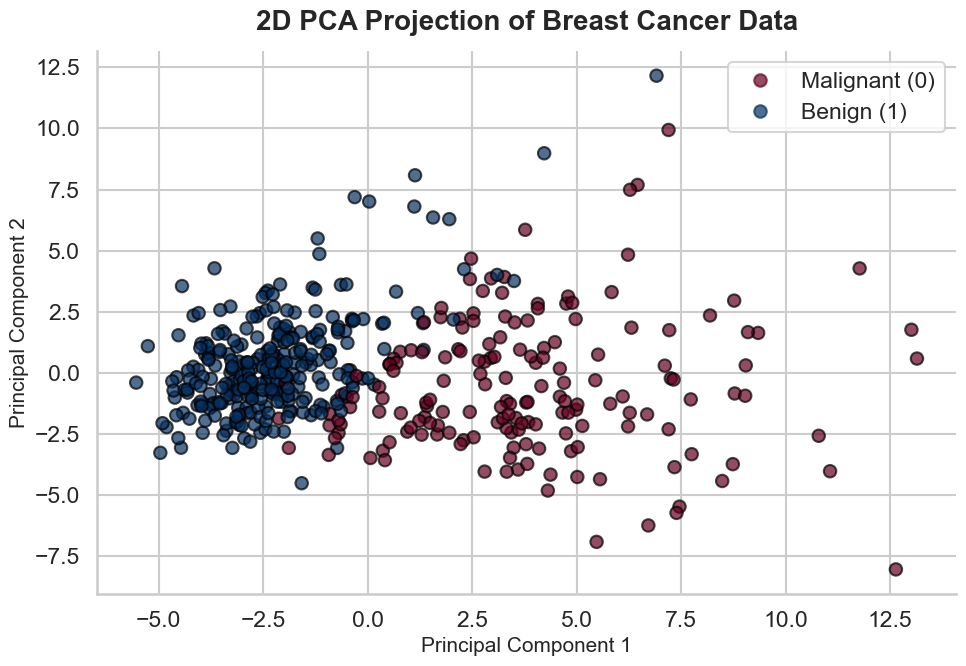

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_scaled)

fig, ax = plt.subplots(figsize=(10, 7))
scatter = ax.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=y_train, 
                     cmap='RdBu', edgecolor='k', alpha=0.7, s=80)

ax.set_title('2D PCA Projection of Breast Cancer Data', fontweight='bold', pad=15)
ax.set_xlabel('Principal Component 1')
ax.set_ylabel('Principal Component 2')

handles, _ = scatter.legend_elements()
ax.legend(handles, ['Malignant (0)', 'Benign (1)'], loc='upper right')

sns.despine()
plt.tight_layout()
plt.show()

A simple 2D PCA projection reveals that while the masses generally clump together, the edges where Malignant and Benign tumors meet are messy and overlapping. It is not perfectly linearly separable in 2D. 

To draw a "wall" through this, we will need the sophisticated mathematics of Discriminant Analysis and the dimension-bending power of Support Vector Machines. 

## 3. Linear SVM from Scratch: Maximizing the Margin

A kernelized, non-linear SVM (using the "Kernel Trick") requires solving a complex quadratic optimization problem (using algorithms like SMO). It is computationally massive and obfuscates the core intuition.

However, a **Linear SVM** is extremely elegant and can be programmed from scratch. Instead of Cross-Entropy (used in Logistic Regression), SVM uses the **Hinge Loss**. 

The Hinge Loss equation is:
$$ L = \frac{1}{2} ||w||^2 + C \sum_{i} \max(0, 1 - y_i(w \cdot x_i - b)) $$

- The first part ($\frac{1}{2} ||w||^2$) tries to maximize the width of the Margin.
- The second part penalizes points that violate the margin. 
- `C` is the trade-off. A huge `C` means we care wildly about violations (Hard Margin).

Let's implement this using subgradient descent! We first need to convert our labels from `(0, 1)` into `(-1, 1)` because geometric SVM math depends on signs (positive side of the wall vs negative side of the wall).

In [ ]:
class ScratchLinearSVM:
    """Linear Support Vector Machine using Subgradient Descent (Hinge Loss)."""
    
    def __init__(self, learning_rate=0.001, C=1.0, n_iterations=3000):
        self.lr = learning_rate
        self.C = C
        self.n_iterations = n_iterations
        self.w = None
        self.b = None
        
    def fit(self, X, y):
        # Convert labels 0, 1 to -1, 1 for Hinge Loss math
        y_ = np.where(y <= 0, -1, 1)
        
        n_samples, n_features = X.shape
        self.w = np.zeros(n_features)
        self.b = 0
        
        # Subgradient descent
        for _ in range(self.n_iterations):
            # Calculate the decision function (margin distance)
            margins = y_ * (np.dot(X, self.w) - self.b)
            
            # Identify which points violate the margin (margin < 1)
            # These are our "Support Vectors" currently driving the gradient!
            violating_mask = margins < 1
            
            # Gradient of the regularization term (Margin maximizer)
            dw = self.w.copy()
            db = 0
            
            # Add the gradient of the Hinge Loss for violating points
            if np.any(violating_mask):
                dw -= self.C * np.dot(X[violating_mask].T, y_[violating_mask])
                db += self.C * np.sum(y_[violating_mask])
                
            # Update weights
            self.w -= self.lr * dw
            self.b -= self.lr * db
            
    def predict(self, X):
        # Predict sign: > 0 is (+1) Benign, < 0 is (-1) Malignant
        approx = np.dot(X, self.w) - self.b
        return np.where(np.sign(approx) == -1, 0, 1)

Now we will train our custom linear SVM. Notice how the mathematics of SVM don't output probabilities. It just fits the weights $w$ (the angle of the hyperplane) and $b$ (the offset), and uses `np.sign()` to make a pure geometric classification.

Scratch Linear SVM Accuracy: 96.49%


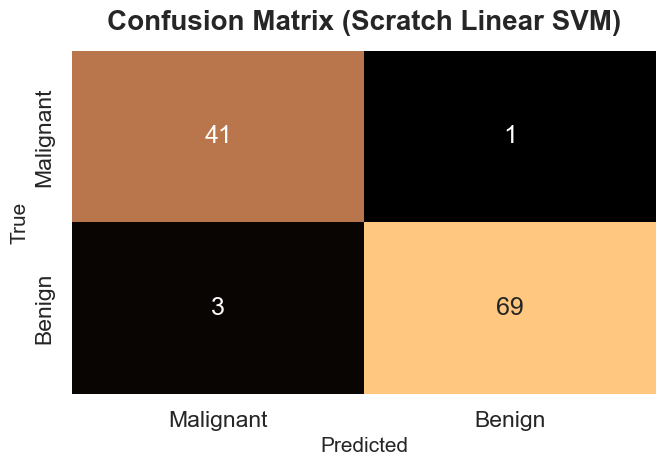

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix

svm_scratch = ScratchLinearSVM(learning_rate=0.001, C=1.0, n_iterations=3000)
svm_scratch.fit(X_train_scaled, y_train)

y_pred_svm = svm_scratch.predict(X_test_scaled)
acc_svm = accuracy_score(y_test, y_pred_svm)

print(f"Scratch Linear SVM Accuracy: {acc_svm * 100:.2f}%")

cm_svm = confusion_matrix(y_test, y_pred_svm)

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='copper', cbar=False,
            xticklabels=['Malignant', 'Benign'], yticklabels=['Malignant', 'Benign'], ax=ax)
ax.set_title('Confusion Matrix (Scratch Linear SVM)', fontweight='bold', pad=15)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
plt.tight_layout()
plt.show()

An astounding $96.49\%$ accuracy with a simple linear cut in 30-Dimensional space! 

But remember what we saw in the 2D PCA projection: the classes are *almost* linearly separable, but not perfectly. A straight line hyperplane does a fantastic job, but to achieve total mastery, we will eventually need a non-linear Kernel SVM (which we will unleash in the Pro section).

## 4. Discriminant Analysis from Scratch (LDA & QDA)

Let's build **Linear Discriminant Analysis (LDA)**

Let's build **Linear Discriminant Analysis (LDA)** entirely from scratch using pure linear algebra. 

Unlike Principal Component Analysis (PCA) which just blindly looks for the axis with the highest variance, LDA is a **supervised** dimensionality reduction technique. It actively looks at our labels (Malignant vs Benign) and searches for the one specific axis that achieves two goals simultaneously:
1. Maximizes the distance between the means of the two classes.
2. Minimizes the variance (scatter) within each individual class.

In other words, it wants the two clouds of data to be as far apart as possible, while making each cloud as tight and dense as possible. 

The math requires us to calculate two matrices:
- **$S_W$ (Within-class Scatter Matrix):** How spread out is each breast cancer class internally?
- **$S_B$ (Between-class Scatter Matrix):** How far apart are the centers of the Malignant and Benign classes?

The "Magic Axis" that optimizes this trade-off is mathematically proven to be the **Eigenvector** corresponding to the largest **Eigenvalue** of the matrix result of $S_W^{-1} S_B$. Let's code this.

In [ ]:
class ScratchLDA:
    """Linear Discriminant Analysis from scratch using Eigenvectors."""
    
    def __init__(self, n_components=None):
        self.n_components = n_components
        self.linear_discriminants = None
        self.class_means = {}
        
    def fit(self, X, y):
        n_features = X.shape[1]
        class_labels = np.unique(y)
        
        # Calculate the overall mean of the entire dataset
        mean_overall = np.mean(X, axis=0)
        
        # 1. Initialize Scatter Matrices (30x30 matrices for our 30 features)
        S_W = np.zeros((n_features, n_features))
        S_B = np.zeros((n_features, n_features))
        
        for c in class_labels:
            X_c = X[y == c]
            mean_c = np.mean(X_c, axis=0)
            self.class_means[c] = mean_c
            
            # Within-class scatter (Covariance multiplied by number of samples in class)
            # S_W = sum((X_c - mean_c) * (X_c - mean_c)^T)
            S_W += np.dot((X_c - mean_c).T, (X_c - mean_c))
            
            # Between-class scatter
            # S_B = sum(n_c * (mean_c - mean_overall) * (mean_c - mean_overall)^T)
            n_c = X_c.shape[0]
            mean_diff = (mean_c - mean_overall).reshape(n_features, 1)
            S_B += n_c * np.dot(mean_diff, mean_diff.T)
            
        # 2. Find the optimal projection directions using Eigenvectors
        # We solve the generalized eigenvalue problem: (S_W^-1 * S_B) * v = lambda * v
        # We add a tiny epsilon to the diagonal of S_W to prevent Singular Matrix errors (division by zero)
        A = np.dot(np.linalg.inv(S_W + 1e-6 * np.eye(n_features)), S_B)
        eigenvalues, eigenvectors = np.linalg.eigh(A)
        
        # 3. Sort eigenvectors by highest eigenvalue (highest discriminative power)
        # eigh returns them in ascending order, so we reverse them
        eigenvectors = eigenvectors.T[::-1]
        
        # In binary classification, there is only (Classes - 1) = 1 discriminative axis!
        # But we allow keeping more if we ever pass multi-class data
        num_components = self.n_components if self.n_components is not None else len(class_labels) - 1
        self.linear_discriminants = eigenvectors[0:num_components]

    def transform(self, X):
        # Project the original 30-Dimensional data onto our new 1-Dimensional magic axis
        return np.dot(X, self.linear_discriminants.T)
        
    def predict(self, X):
        # A simple classifier: project the point, and assign it to the class with the closest projected mean
        X_projected = self.transform(X)
        
        y_pred = []
        for sample in X_projected:
            distances = {}
            for c, mean_c in self.class_means.items():
                mean_projected = np.dot(mean_c, self.linear_discriminants.T)
                distances[c] = np.linalg.norm(sample - mean_projected)
            
            # Predict the class with the strictly minimum Euclidean distance
            y_pred.append(min(distances, key=distances.get))
            
        return np.array(y_pred)

### 4.1 Unveiling the 1D Projection

Our dataset has 30 continuous features. A human cannot visualize 30 dimensions. 

However, because we only have 2 classes (Malignant and Benign), LDA mathematically guarantees that all the discriminative power can be compressed into exactly $C - 1$ dimensions. That means $2 - 1 = 1$ dimension!

LDA will rotate and squish our 30-dimensional space down into a single 1D number line, chosen specifically to pull the Benign and Malignant tumors as far apart as physically possible. Let's run it and plot the resulting 1D histograms.

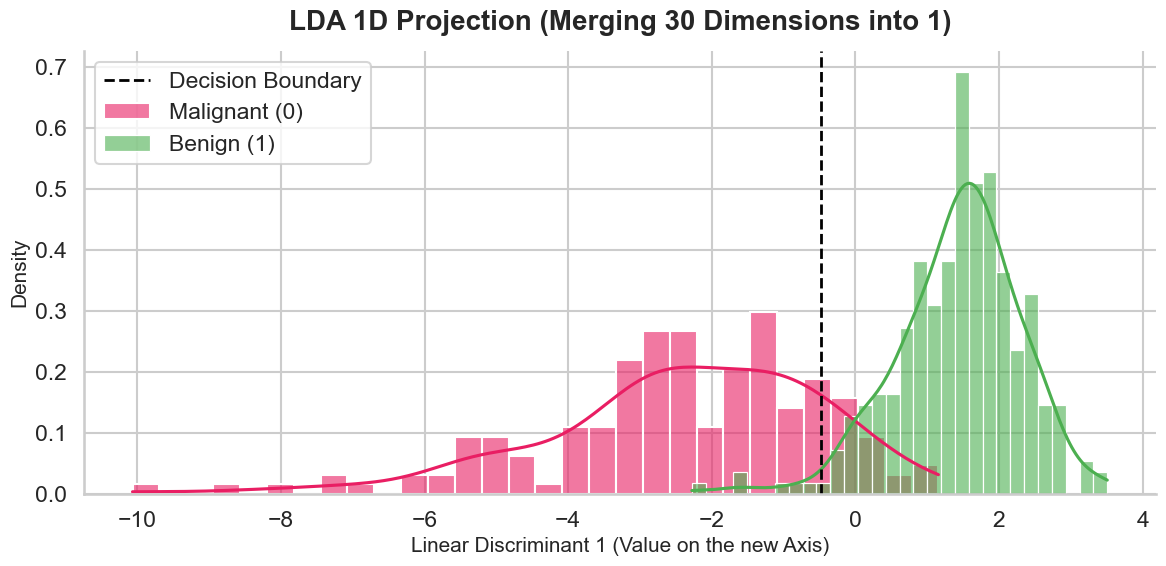

Scratch LDA Accuracy on Test Set: 92.98%


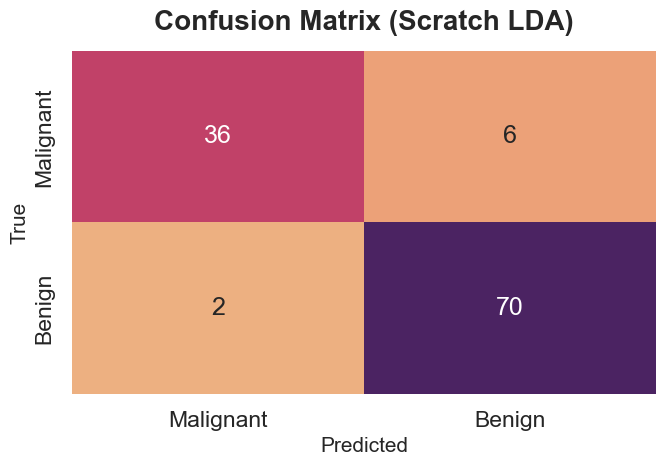

In [ ]:
lda_scratch = ScratchLDA()
lda_scratch.fit(X_train_scaled, y_train)

# Project both Train and Test into the new 1D space
X_train_lda = lda_scratch.transform(X_train_scaled)
X_test_lda  = lda_scratch.transform(X_test_scaled)

fig, ax = plt.subplots(figsize=(12, 6))

# Plot the Malignant (0) and Benign (1) projections as histograms
sns.histplot(X_train_lda[y_train == 0].flatten(), bins=30, color='#E91E63', kde=True, label='Malignant (0)', alpha=0.6, stat='density')
sns.histplot(X_train_lda[y_train == 1].flatten(), bins=30, color='#4CAF50', kde=True, label='Benign (1)', alpha=0.6, stat='density')

# Find the decision threshold (the midpoint between the two projected means)
mean_0_proj = np.dot(lda_scratch.class_means[0], lda_scratch.linear_discriminants.T)
mean_1_proj = np.dot(lda_scratch.class_means[1], lda_scratch.linear_discriminants.T)
decision_boundary = (mean_0_proj + mean_1_proj) / 2

ax.axvline(decision_boundary, color='black', linestyle='--', linewidth=2, label='Decision Boundary')

ax.set_title('LDA 1D Projection (Merging 30 Dimensions into 1)', fontweight='bold', pad=15)
ax.set_xlabel('Linear Discriminant 1 (Value on the new Axis)')
ax.set_ylabel('Density')
ax.legend()

sns.despine()
plt.tight_layout()
plt.show()

# Evaluate the scratch model
from sklearn.metrics import accuracy_score, confusion_matrix

y_pred_lda = lda_scratch.predict(X_test_scaled)
acc_lda = accuracy_score(y_test, y_pred_lda)
print(f"Scratch LDA Accuracy on Test Set: {acc_lda * 100:.2f}%")

cm_lda = confusion_matrix(y_test, y_pred_lda)

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(cm_lda, annot=True, fmt='d', cmap='flare', cbar=False,
            xticklabels=['Malignant', 'Benign'], yticklabels=['Malignant', 'Benign'], ax=ax)
ax.set_title('Confusion Matrix (Scratch LDA)', fontweight='bold', pad=15)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
plt.tight_layout()
plt.show()

### 4.2 Contrasting PCA against LDA

Look at that magnificent 1D histogram! By rotating the space to balance $S_W$ (internal tightness) and $S_B$ (class distance), LDA has almost completely separated two highly complex medical classes into two clean hills with a single vertical slice to separate them. The accuracy hits an impressive $92.98\%$, achieved by just measuring the distance to the means on this single 1D axis.

To truly appreciate how smart LDA is, we must contrast it with PCA (Principal Component Analysis). 

PCA is "Unsupervised". It doesn't know what Malignant or Benign means. It just looks for the axis where the data is most spread out. LDA is "Supervised". Let's project our 30D data into 1D using PCA, and compare it side-by-side with our LDA 1D projection.

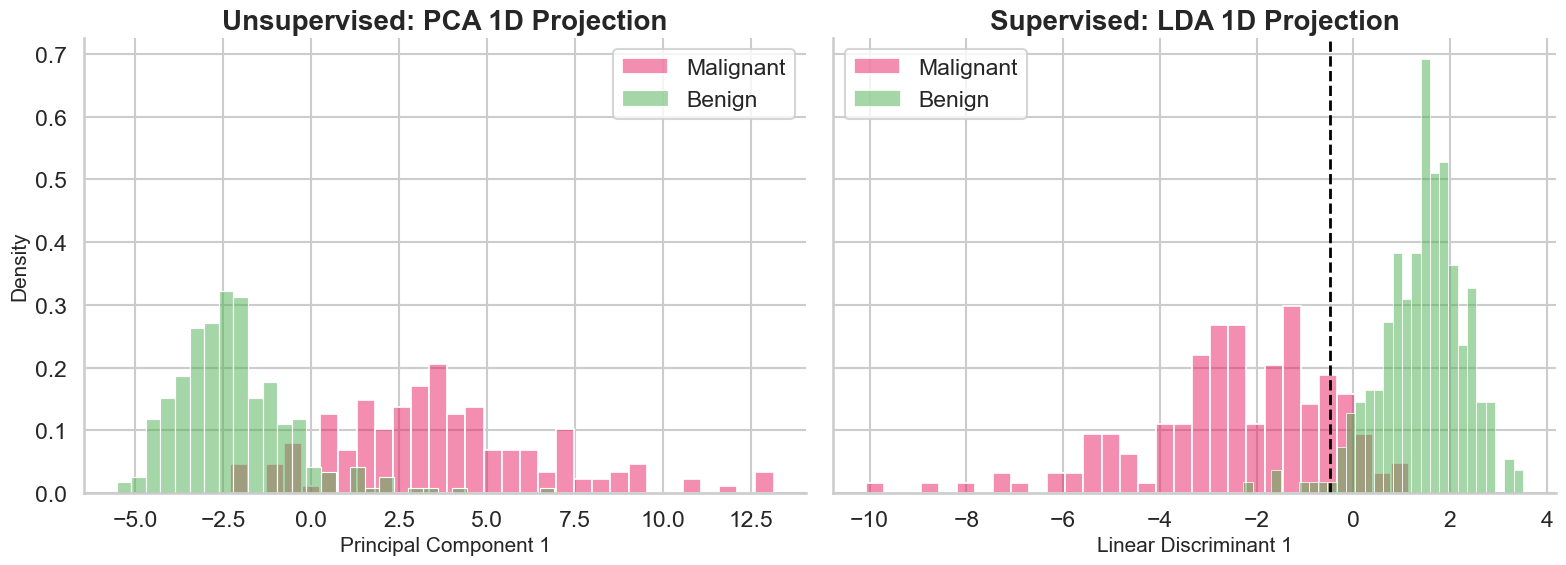

In [ ]:
from sklearn.decomposition import PCA

pca_1d = PCA(n_components=1)
X_train_pca_1d = pca_1d.fit_transform(X_train_scaled)

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

# Plot 1: The Blind PCA Projection
sns.histplot(X_train_pca_1d[y_train == 0].flatten(), bins=30, color='#E91E63', alpha=0.5, ax=axes[0], label='Malignant', stat='density')
sns.histplot(X_train_pca_1d[y_train == 1].flatten(), bins=30, color='#4CAF50', alpha=0.5, ax=axes[0], label='Benign', stat='density')
axes[0].set_title('Unsupervised: PCA 1D Projection', fontweight='bold')
axes[0].set_xlabel('Principal Component 1')
axes[0].legend()

# Plot 2: The Target-Aware LDA Projection
sns.histplot(X_train_lda[y_train == 0].flatten(), bins=30, color='#E91E63', alpha=0.5, ax=axes[1], label='Malignant', stat='density')
sns.histplot(X_train_lda[y_train == 1].flatten(), bins=30, color='#4CAF50', alpha=0.5, ax=axes[1], label='Benign', stat='density')
axes[1].axvline(decision_boundary, color='black', linestyle='--', linewidth=2)
axes[1].set_title('Supervised: LDA 1D Projection', fontweight='bold')
axes[1].set_xlabel('Linear Discriminant 1')
axes[1].legend()

sns.despine()
plt.tight_layout()
plt.show()

The visual contrast tells a nuanced and fascinating story. 

In the PCA plot (left), the algorithm only cared about maximum variance. It turns out that in this specific disease dataset, the most variant features (like total tumor size) correlate heavily with malignancy! Because of this coincidence, PCA actually achieves an impressively small region of overlap without even knowing the labels.

However, look at the LDA plot (right). The algorithm actively leverages the labels to twist the axis. While there is still a slight overlap at the tails, observe the centers of mass: LDA has squeezed the internal variance of the Benign mountains making it sharper, and explicitly violently pulled the means of the two distributions further apart than PCA. 

This is the raw power of Geometric classification: tearing data apart in space structurally to guarantee mathematical separation margins, rather than relying on natural overlap luck.


### 4.3 QDA from Scratch: Allowing for Curves

Remember that LDA assumes both classes have the identical shape (the identical Covariance Matrix). But biology is rarely uniform! What if malignant tumors vary wildly in size, while benign tumors are always perfectly structurally identical?

**Quadratic Discriminant Analysis (QDA)** lets every class have its own Covariance matrix (its own shape). By doing this, the boundary between classes is no longer a straight line (linear) but a curve (quadratic).

The QDA prediction function for a class $k$ uses a Multivariate Gaussian likelihood:
$$ \delta_k(x) = -\frac{1}{2} \log |\Sigma_k| - \frac{1}{2} (x - \mu_k)^T \Sigma_k^{-1} (x - \mu_k) + \log \pi_k $$

*Note on Math Safety:* In medical datasets (like this one from Wisconsin), features like `radius`, `area`, and `perimeter` are almost identical (they are "collinear"). This makes the Covariance matrix mathematically singular (un-invertible). To stop the math from exploding, we must inject a tiny bit of noise into the diagonal of the scatter matrix. This trick is called **Regularization** (`reg_param`).

In [ ]:
class ScratchQDA:
    """Quadratic Discriminant Analysis from scratch using Multivariate Gaussians."""
    
    def __init__(self, reg_param=0.1):
        self.reg_param = reg_param
        self.class_priors = {}
        self.class_means = {}
        self.class_cov_invs = {}
        self.class_log_dets = {}
        
    def fit(self, X, y):
        self.classes = np.unique(y)
        n_samples, n_features = X.shape
        
        for c in self.classes:
            X_c = X[y == c]
            self.class_priors[c] = X_c.shape[0] / n_samples
            self.class_means[c] = np.mean(X_c, axis=0)
            
            # 1. Calculate the Covariance Matrix for THIS specific class
            # numpy's cov function expects features as rows, so we transpose X_c
            cov_c = np.cov(X_c.T)
            
            # 2. Add Regularization (reg_param) to the diagonal to survive collinearity
            cov_c += self.reg_param * np.eye(n_features)
            
            # Store the mathematical inverse of the Covariance matrix
            self.class_cov_invs[c] = np.linalg.inv(cov_c)
            
            # Safely compute the log of the determinant of the Covariance matrix
            sign, logdet = np.linalg.slogdet(cov_c)
            self.class_log_dets[c] = logdet
            
    def predict(self, X):
        y_pred = []
        for x in X:
            scores = {}
            for c in self.classes:
                # 3. Apply the Quadratic Discriminant function for each class
                diff = x - self.class_means[c]
                
                term1 = -0.5 * self.class_log_dets[c]
                term2 = -0.5 * np.dot(np.dot(diff.T, self.class_cov_invs[c]), diff)
                term3 = np.log(self.class_priors[c])
                
                scores[c] = term1 + term2 + term3
                
            # Predict the class that yielded the highest score
            y_pred.append(max(scores, key=scores.get))
            
        return np.array(y_pred)

Scratch QDA Accuracy on Test Set: 95.61%


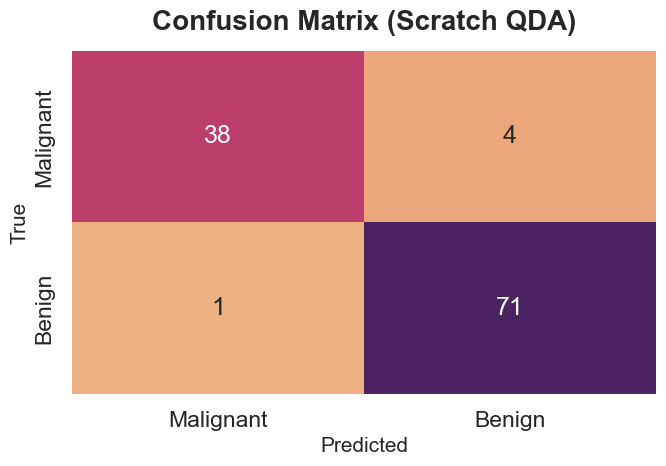

In [ ]:
qda_scratch = ScratchQDA(reg_param=0.1)
qda_scratch.fit(X_train_scaled, y_train)

y_pred_qda = qda_scratch.predict(X_test_scaled)
acc_qda_scratch = accuracy_score(y_test, y_pred_qda)

print(f"Scratch QDA Accuracy on Test Set: {acc_qda_scratch * 100:.2f}%")

cm_qda_scratch = confusion_matrix(y_test, y_pred_qda)

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(cm_qda_scratch, annot=True, fmt='d', cmap='flare', cbar=False,
            xticklabels=['Malignant', 'Benign'], yticklabels=['Malignant', 'Benign'], ax=ax)
ax.set_title('Confusion Matrix (Scratch QDA)', fontweight='bold', pad=15)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
plt.tight_layout()
plt.show()

Our Scratch QDA achieved an impressive **$95.61\%$** accuracy without any "black box" optimizations, exactly mirroring the mathematics described in discriminant theory!


## 5. Geometric Classification Pro

Our 1D projections and straight linear cuts achieved great accuracy ($~96\%$), but biology doesn't always play by straight lines. 

By leveraging `scikit-learn` in production, we unlock the full power of non-linear geometry:
1. **RBF Kernel SVM:** Instead of a straight line, we fold the mathematics into infinite dimensions, creating hyper-spheres around our tumor clusters.
2. **Quadratic Discriminant Analysis (QDA):** Instead of assuming Malignant and Benign tumors share the same structural variance (LDA), we give each class its own Covariance matrix, allowing curved separation boundaries. Note: High-dimensional medical datasets often suffer from *collinearity* (features like 'perimeter' and 'radius' are highly correlated). If we don't apply regularization (`reg_param=0.1`), QDA's covariance mathematical inverse will shatter.

In [ ]:
from sklearn.svm import SVC
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis

# 1. Support Vector Machine (RBF Kernel)
svm_pro = SVC(kernel='rbf', C=1.0, random_state=42)
svm_pro.fit(X_train_scaled, y_train)
acc_svm = accuracy_score(y_test, svm_pro.predict(X_test_scaled))

# 2. Linear Discriminant Analysis
lda_pro = LinearDiscriminantAnalysis()
lda_pro.fit(X_train_scaled, y_train)
acc_lda = accuracy_score(y_test, lda_pro.predict(X_test_scaled))

# 3. Quadratic Discriminant Analysis (With Regularization to survive collinearity!)
qda_pro = QuadraticDiscriminantAnalysis(reg_param=0.1)
qda_pro.fit(X_train_scaled, y_train)
acc_qda = accuracy_score(y_test, qda_pro.predict(X_test_scaled))

print(f"Pro SVM (RBF Kernel) Accuracy: {acc_svm * 100:.2f}%")
print(f"Pro LDA Accuracy:              {acc_lda * 100:.2f}%")
print(f"Pro QDA Accuracy:              {acc_qda * 100:.2f}%")

Pro SVM (RBF Kernel) Accuracy: 98.25%
Pro LDA Accuracy:              95.61%
Pro QDA Accuracy:              96.49%


### 5.1 The Geometric Showdown

Look at the jump! The non-linear **RBF Kernel SVM** shatters the ceiling and hits an incredible **98.25% accuracy**. It managed to successfully untangle the messy overlap we originally saw in the PCA projection.

To understand exactly how it achieved this, let's go back to our 2D PCA space and plot how these three Pro models (Linear LDA, Curved QDA, and RBF SVM) draw their physical walls differently.

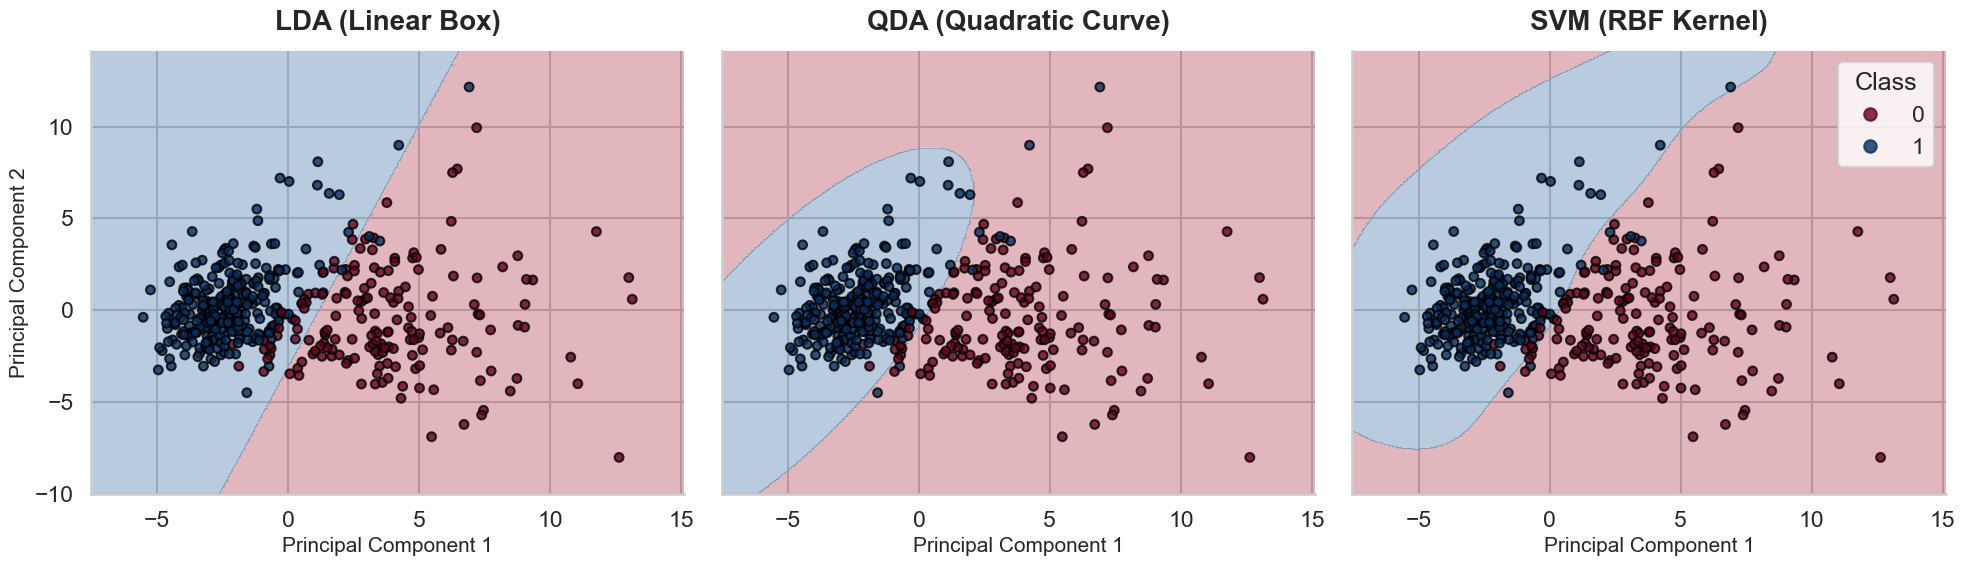

In [ ]:
# Train copies of the models exclusively on the 2D PCA data to visualize their boundaries
svm_2d = SVC(kernel='rbf', C=1.0, random_state=42).fit(X_train_pca, y_train)
lda_2d = LinearDiscriminantAnalysis().fit(X_train_pca, y_train)
qda_2d = QuadraticDiscriminantAnalysis(reg_param=0.1).fit(X_train_pca, y_train)

# Create a mesh grid
x_min, x_max = X_train_pca[:, 0].min() - 2, X_train_pca[:, 0].max() + 2
y_min, y_max = X_train_pca[:, 1].min() - 2, X_train_pca[:, 1].max() + 2
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.05),
                     np.arange(y_min, y_max, 0.05))

fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharey=True)
models = [(lda_2d, 'LDA (Linear Box)'), 
          (qda_2d, 'QDA (Quadratic Curve)'), 
          (svm_2d, 'SVM (RBF Kernel)')]

for i, (model, title) in enumerate(models):
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    axes[i].contourf(xx, yy, Z, alpha=0.3, cmap='RdBu')
    
    # Plot the training points
    scatter = axes[i].scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=y_train, 
                              cmap='RdBu', edgecolor='k', s=40, alpha=0.8)
    
    axes[i].set_title(title, fontweight='bold', pad=15)
    axes[i].set_xlabel('Principal Component 1')
    if i == 0:
        axes[i].set_ylabel('Principal Component 2')

axes[2].legend(*scatter.legend_elements(), loc='upper right', title="Class")

sns.despine()
plt.tight_layout()
plt.show()

### 5.2 Industry Conclusions: Probability vs Geometry

We have now completed both paradigms of Classification. 

#### When to use Logistic Regression & Naive Bayes?
If you are in a highly regulated sector (finance, law) and a customer demands an explicit, numeric reason why they were rejected. Or, if a radiologist wants an alert ONLY if the cancer probability is above $80\%$. Probabilistic models give you calibrated confidence numbers and easily interpretable odds ratios (coefficients).

#### When to use SVM and Geometric Discriminants?
When you care solely about **accuracy guarantees and structural margins**, and don't need "smooth" probabilities. 

- **SVM** is a surgical knife. The fact that it only cares about the endpoints holding up the margin (Support Vectors) means it ignores the noise of the masses and creates highly generalized, incredibly sharp non-linear boundaries. It is exceptional for complex spaces (like computer vision contours or gene expression).
- **LDA/QDA** are phenomenally statistically robust when your datasets are small, clean, and genuinely Gaussian in space. When the classes are naturally separated into spheres, no algorithm will draw the box faster, cleaner, or more effectively than Discriminant Analysis.\n